# 06. Weighted ViT-B/16 for Melanoma Classification

**Objective**  
The objective of this experiment is to establish a **baseline Vision Transformer (ViT)** model for binary image classification. Specifically, we use a pretrained **ViT-B/16** model and adapt it to classify images into two classes (e.g., melanoma vs nevus).

**Model Architecture**

| Stage | Layers |
| --- | --- |
| Input | RGB dermoscopic image |
| Patch embedding | `16 × 16` image patches |
| Backbone | Pretrained `ViT-B/16` |
| Classification head | Final linear layer with `1` output |
| Output | Single logit for melanoma probability |

### Hypothesis

The Vision Transformer is expected to perform competitively with or better than CNN models due to its ability to capture **global relationships across the image** through self-attention.

### Summary of This Notebook

- Uses a **pretrained ViT-B/16 model** as the baseline transformer for binary classification  
- Replaces the original classification head with a **single-output layer (1 logit)**  
- Performs **full fine-tuning** (no freezing), meaning all model parameters are updated during training


### 1. Setup and Imports

This section loads the project modules, trainer utilities, and shared evaluation helpers, then selects the available compute device (`CUDA`, `MPS`, or `CPU`).  
The ViT classifier is imported from the project source so this notebook remains aligned with the reusable model implementation in `src.models.vit`.


In [ ]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.vit import ViTBinaryClassifier
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
from src.data.transform import get_augmented_train_transforms

import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


### 2. Data Split and Weighted-Loss Configuration

The dataset is loaded using the predefined train, validation, and test CSV splits.  
This experiment replaces the CNN backbone with `ViTBinaryClassifier`, while keeping weighted BCE loss to address class imbalance:

- `ViTBinaryClassifier` as the feature extractor and classifier
- `BCEWithLogitsLoss(pos_weight=...)` to penalize missed melanoma more strongly
- `Adam` optimizer with a smaller learning rate `1e-4` for stable transformer fine-tuning
- Batch size `32` and image size `224 × 224` to match the ViT input format


In [5]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / "data_new/splits/train.csv"),
    val_csv=str(ROOT / "data_new/splits/val.csv"),
    test_csv=str(ROOT / "data_new/splits/test.csv"),
    image_dir=str(ROOT / "data_new/images/train"),
    test_image_dir=str(ROOT / "data_new/images/test"),
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=224),
)

train_df = pd.read_csv(ROOT / "data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()
num_nevus = (train_df["label"] == 0).sum()
pos_weight_value = num_nevus / num_melanoma

print(f"Training samples: {len(train_df)}")
print(f"Melanoma: {num_melanoma}")
print(f"Nevus: {num_nevus}")
print(f"pos_weight: {pos_weight_value:.4f}")

model = ViTBinaryClassifier(pretrained=True, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
)
optimizer = optim.Adam(model.parameters(), lr=1e-4)


Training samples: 7991
Melanoma: 877
Nevus: 7114
pos_weight: 8.1117


### 3. Train the Weighted ViT-B/16 Model

The model is trained for `10` epochs using the pretrained ViT backbone with weighted BCE loss.  
Training and validation metrics are stored as lists of dictionaries so they can be passed directly into the shared plotting function later. The checkpoint with the highest validation AUC is saved.


In [6]:
num_epochs = 10

best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
          f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
          f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/vit_b16_weighted.pth')
        print("  Saved best model.")


Epoch [1/10]
  Train | Loss: 0.9887, Bal Acc: 0.7099, Recall: 0.7742, F2: 0.5061, AUC: 0.7820
  Val   | Loss: 0.8471, Bal Acc: 0.7726, Recall: 0.8729, F2: 0.5933, AUC: 0.8581
  Saved best model.


Epoch [2/10]
  Train | Loss: 0.9247, Bal Acc: 0.7479, Recall: 0.8244, F2: 0.5504, AUC: 0.8156
  Val   | Loss: 0.8866, Bal Acc: 0.7708, Recall: 0.8644, F2: 0.5913, AUC: 0.8470


Epoch [3/10]
  Train | Loss: 0.8443, Bal Acc: 0.7653, Recall: 0.8233, F2: 0.5719, AUC: 0.8469
  Val   | Loss: 0.8603, Bal Acc: 0.7523, Recall: 0.9195, F2: 0.5702, AUC: 0.8561


Epoch [4/10]
  Train | Loss: 0.8582, Bal Acc: 0.7562, Recall: 0.8210, F2: 0.5605, AUC: 0.8407
  Val   | Loss: 0.9007, Bal Acc: 0.7399, Recall: 0.8305, F2: 0.5546, AUC: 0.8291


Epoch [5/10]
  Train | Loss: 0.8305, Bal Acc: 0.7725, Recall: 0.8404, F2: 0.5807, AUC: 0.8505
  Val   | Loss: 0.8371, Bal Acc: 0.7749, Recall: 0.8898, F2: 0.5959, AUC: 0.8667
  Saved best model.


Epoch [6/10]
  Train | Loss: 0.8363, Bal Acc: 0.7699, Recall: 0.8369, F2: 0.5774, AUC: 0.8480
  Val   | Loss: 0.7992, Bal Acc: 0.7740, Recall: 0.8517, F2: 0.5954, AUC: 0.8687
  Saved best model.


Epoch [7/10]
  Train | Loss: 0.8218, Bal Acc: 0.7765, Recall: 0.8506, F2: 0.5854, AUC: 0.8533
  Val   | Loss: 0.7906, Bal Acc: 0.7792, Recall: 0.8347, F2: 0.6024, AUC: 0.8736
  Saved best model.


Epoch [8/10]
  Train | Loss: 0.7883, Bal Acc: 0.7845, Recall: 0.8426, F2: 0.5965, AUC: 0.8661
  Val   | Loss: 0.8296, Bal Acc: 0.7895, Recall: 0.8686, F2: 0.6149, AUC: 0.8677


Epoch [9/10]
  Train | Loss: 0.8215, Bal Acc: 0.7730, Recall: 0.8426, F2: 0.5812, AUC: 0.8525
  Val   | Loss: 0.8388, Bal Acc: 0.7542, Recall: 0.8686, F2: 0.5717, AUC: 0.8536


Epoch [10/10]
  Train | Loss: 0.7840, Bal Acc: 0.7880, Recall: 0.8540, F2: 0.6006, AUC: 0.8706
  Val   | Loss: 0.8111, Bal Acc: 0.7721, Recall: 0.9195, F2: 0.5922, AUC: 0.8703


### 4. Plot Training Curves

This notebook uses the shared evaluation utility to render the standard 2 × 2 dashboard: Loss, Balanced Accuracy, Recall, and F2.  
This keeps the ViT experiment directly comparable with the earlier CNN notebooks.


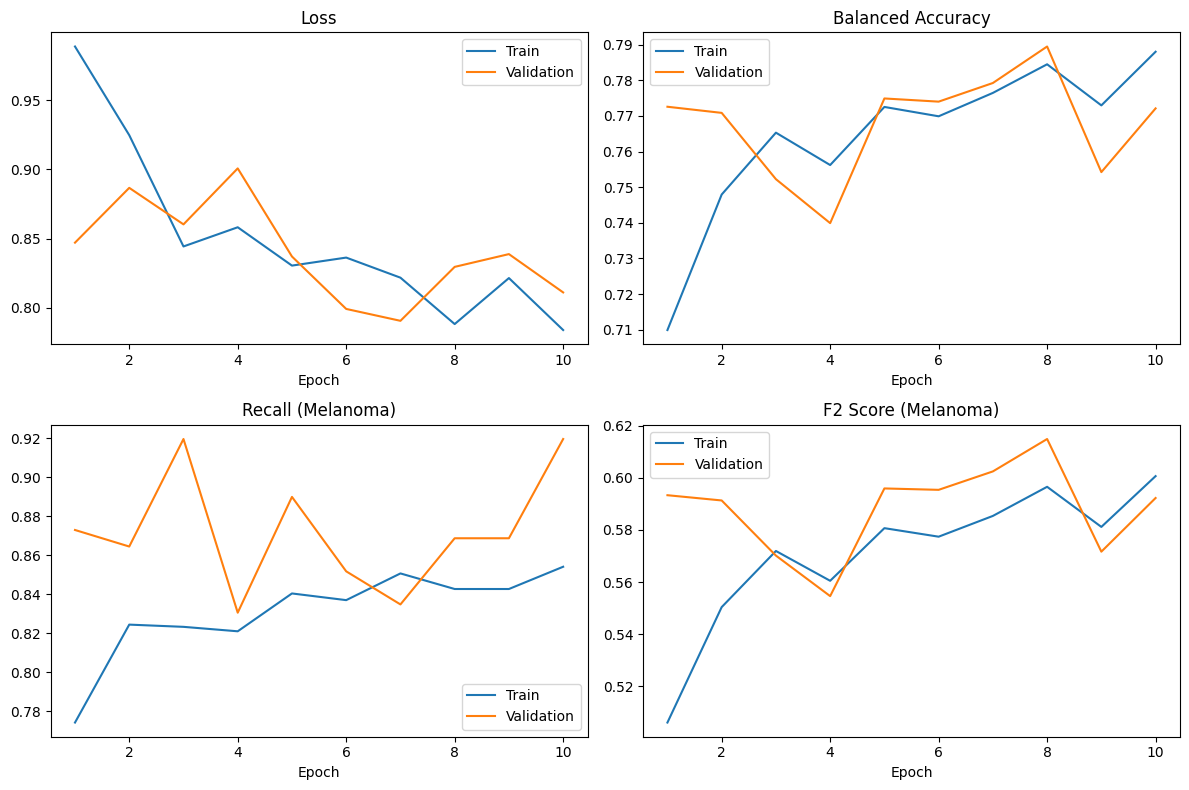

In [7]:
plot_training_curves(train_history, val_history)


### 5. Tune the Classification Threshold on the Validation Set

The loss is weighted during training, but the classification threshold still needs to be chosen separately.  
This step reloads the best saved checkpoint and finds the probability threshold that maximizes **F2 score** on the validation set.


In [8]:
model.load_state_dict(torch.load(ROOT / 'models/vit_b16_weighted.pth', map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F2: {best_f2:.4f}")


Best threshold: 0.51 | Val F2: 0.6088
Best validation threshold: 0.51
Best validation F2: 0.6088


### 6. Evaluate on the Test Set

The best weighted ViT-B/16 checkpoint is evaluated on the held-out test set using the threshold selected on the validation set.  
The shared evaluation utility reports AUC-ROC, balanced accuracy, F2 score, a classification report, and visual diagnostics such as the confusion matrix and ROC curve.


Threshold:          0.51
AUC-ROC:            0.8837
Balanced Accuracy:  0.7826
F2 Score:           0.6005

              precision    recall  f1-score   support

Non-Melanoma     0.9729    0.7231    0.8296      1340
    Melanoma     0.2796    0.8421    0.4198       171

    accuracy                         0.7366      1511
   macro avg     0.6263    0.7826    0.6247      1511
weighted avg     0.8944    0.7366    0.7832      1511



/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


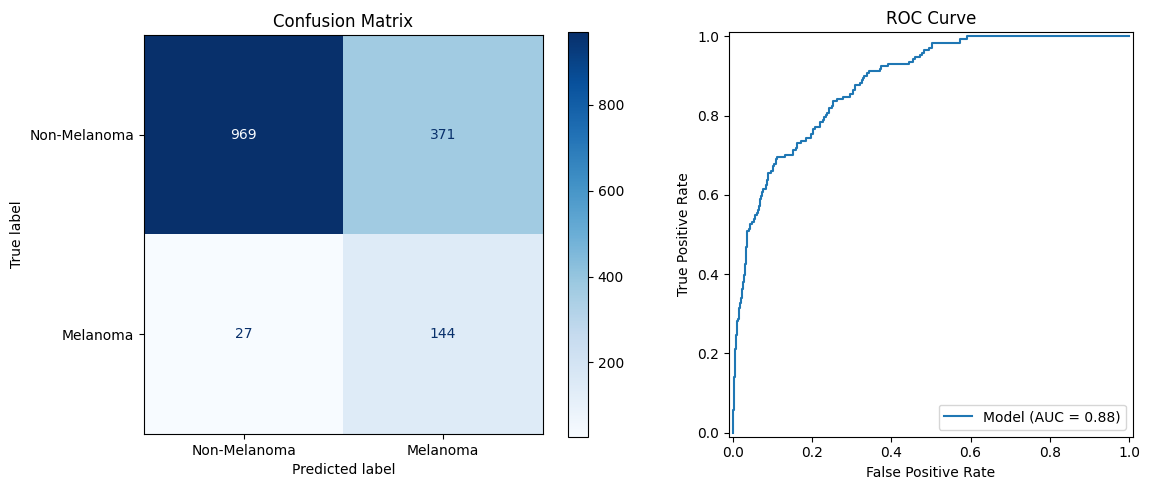

In [9]:
evaluate_model(model, test_loader, device, threshold=best_threshold)


### Results Summary (Weighted ViT-B/16)

### 7. Baseline Interpretation

### Key Metrics
- **AUC-ROC:** ~0.884  
- **Best Threshold:** 0.51  
- **F2 Score:** ~0.601  
- **Balanced Accuracy:** ~0.783  

### Class-wise Performance
- **Melanoma Recall:** ~0.842  
- **Melanoma Precision:** ~0.280  
- **Non-melanoma Precision:** ~0.973  

### Key Observations
- Model shows **strong ranking ability** with a high AUC-ROC
- Threshold tuning to **0.51** gives a better F2-oriented operating point
- The model achieves **high melanoma recall**, which is important for screening
- Trade-off: higher melanoma recall comes with **many false positives** and low melanoma precision

### Conclusion
- Strong weighted ViT baseline for **capturing melanoma patterns**
- Performs well as a **high-sensitivity classifier** after threshold tuning
- Still not ideal as a standalone diagnostic model because **precision remains low**
- Future improvements should focus on:
  - Better precision-recall balance
  - Reducing false positives while keeping recall high
